Phase 1:
Importing data from SDSS DR12 database.

In [1]:
# importing the labeled Galaxy Clusters via Vizier from Tempel's SDSS DR12 catalog
from astroquery.vizier import Vizier
import pandas as pd
vizier = Vizier(row_limit=-1)
print("Querying Vizier for galaxy cluster data...")
catalogs = vizier.get_catalogs("J/A+A/602/A100")
print("Found these tables: \n")
print(catalogs.keys())

#defines the cosmology
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3) 

# SDSS apparent magnitude limit for the main galaxy sample
apparent_magnitude_limit = 17.77

# Since we can't work with the entire database, we choose a limited volume of the space to work with.(Redshifts between 0.04 and 0.1)
z_min = 0.04
z_max = 0.1

# then we must Calculate the absolute magnitude limit at the FAR edge of our limited volume.
# Any galaxy fainter than this wouldn't be detectable at z_max. (M = m - mu)
mu_max = cosmo.distmod(z_max).value
M_limit = apparent_magnitude_limit - mu_max
print(f"Absolute magnitude limit at z={z_max}: {M_limit:.2f}")

# 1. Grab the first table (the galaxy list)
df = catalogs[0].to_pandas()

# 2. Keep only the columns we actually need for the math and the network
cosmic_df = df[['objID', 'RAJ2000', 'DEJ2000', 'zobs', 'rmag', 'GroupID']].copy()

# 3. Rename them to simple, standard variables
cosmic_df.rename(columns={
    'RAJ2000': 'ra', 
    'DEJ2000': 'dec', 
    'zobs': 'z', 
    'GroupID': 'True_Cluster_ID',
    'rmag': 'm'
}, inplace=True)

# calculate the absolute magnitude for each galaxy (M = m - mu)
cosmic_df['M'] = cosmic_df['m'] - cosmo.distmod(cosmic_df['z']).value

# 4. Filter the data to a specific "slice" of the universe (Redshift between 0.04 and 0.1)
# also filter to only include galaxies brighter than the derived absolute magnitude limit

my_galaxies = cosmic_df[
    (cosmic_df['z'] >= z_min) & 
    (cosmic_df['z'] <= z_max) &
    (cosmic_df['M'] <= M_limit)
    ].copy()

# Reset the index to be clean
my_galaxies.reset_index(drop=True, inplace=True)

print("Data prepped! Here are the first 5 galaxies:")
print(my_galaxies.head())

Querying Vizier for galaxy cluster data...
Found these tables: 

['J/A+A/602/A100/table1', 'J/A+A/602/A100/table2', 'J/A+A/602/A100/table3']
Absolute magnitude limit at z=0.1: -20.55
Data prepped! Here are the first 5 galaxies:
                 objID          ra        dec         z          m  \
0  1237667142858899835  121.947446  16.394023  0.098985  17.590959   
1  1237668496313548897  163.460551  16.849785  0.088582  13.753721   
2  1237668496313549020  163.503459  16.812010  0.083779  15.136902   
3  1237668496313549044  163.511480  16.857817  0.085634  15.488796   
4  1237668496313549213  163.563531  16.907510  0.086201  15.904251   

   True_Cluster_ID          M  
0                1 -20.700612  
1                5 -24.281438  
2                5 -22.770078  
3                5 -22.468503  
4                5 -22.068228  


Phase 2:
At this point, We need to convert our spherical coordinates (d, $\alpha , \delta$) to cartesian coordinates (X,Y,Z).

first, we need to calculate the comoving distance for each galaxy using it's redshift.

second, now that we have our physical distance(d), and our angles("ra" as $\alpha$ and "dec" as $\delta$), we can apply standard spherical to cartesian transformations:

$ X = dcos(\delta)cos(\alpha) $

$ Y = dcos(\delta)sin(\alpha) $

$ Z = dsin(\delta) $



we can make it more Scientific and write some Professional looking code by using astropy library.

In [2]:
from astropy import units as u
from astropy.coordinates import SkyCoord

#calculate distance from redshift
my_galaxies['distance_mpc'] = cosmo.comoving_distance(my_galaxies['z']).to(u.Mpc).value

#summon the skycoord and let it do its magic
coords = SkyCoord(
    ra=my_galaxies['ra'].values * u.degree,
    dec=my_galaxies['dec'].values * u.degree,
    distance=my_galaxies['distance_mpc'].values * u.Mpc
)

#extract the 3D coordinates
my_galaxies['X'] = coords.cartesian.x.value
my_galaxies['Y'] = coords.cartesian.y.value
my_galaxies['Z'] = coords.cartesian.z.value

print("Phase 2 Complete! Here are the 3D coordinates:")
print(my_galaxies[['objID', 'X', 'Y', 'Z', 'True_Cluster_ID']].head())

Phase 2 Complete! Here are the 3D coordinates:
                 objID           X           Y           Z  True_Cluster_ID
0  1237667142858899835 -210.313954  337.260652  116.934621                1
1  1237668496313548897 -341.005876  101.265986  107.736869                5
2  1237668496313549020 -323.020025   95.661677  101.789349                5
3  1237668496313549044 -329.961638   97.667183  104.272763                5
4  1237668496313549213 -332.104615   97.973443  105.249775                5


Phase 3:
We need to pass the coordinates of each galaxy (node) to the network. We also need a linking length ($r_c$). If the distance between two galaxies is smaller than this length, they will be connected via an edge.

For this purpose, we take 3 steps: 

1. **Form our tree of nodes** using a KDTree for efficiency.

2. **Identify the linking length ($r_c$)** by finding the percolation threshold. We search the range of $1$ Mpc $\leq r_c \leq 25$ Mpc.
   * We plot the size of the Giant Connected Component (GCC) against $r_c$.
   * We use a **heuristic selection rule**: choosing the $r_c$ where the GCC growth rate (gradient) is maximized. This identifies the "phase transition" where the cosmic web structure begins to dominate the topology.

3. **Form the final network graph** using the chosen $r_c$.

In [3]:
import networkx as nx
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

# build a KDTree for efficient neighbor searching
coordinates = my_galaxies[['X', 'Y', 'Z']].values
tree = KDTree(coordinates)
number_of_galaxies = len(my_galaxies)

# Search for rc across a broader range to capture the transition
rc_values = np.arange(1.0, 25.0, 0.5)
gcc_coverage_percentages = []

print("Scanning linking lengths for percolation threshold...")
for rc in rc_values:
    edges = tree.query_pairs(rc)
    temp_graph = nx.Graph()
    temp_graph.add_nodes_from(range(number_of_galaxies))
    temp_graph.add_edges_from(edges)

    if len(temp_graph.edges) > 0:
        largest_cluster = max(nx.connected_components(temp_graph), key=len)
        gcc_coverage = len(largest_cluster)
    else:
        gcc_coverage = 1

    gcc_coverage_percentage = (gcc_coverage / number_of_galaxies) * 100
    gcc_coverage_percentages.append(gcc_coverage_percentage)

# Selection Rule: Maximum Gradient (Heuristic Estimate)
gradients = np.gradient(gcc_coverage_percentages)
r_c = rc_values[np.argmax(gradients)]
print(f"Heuristic connection radius (rc): {r_c} Mpc")

Optimal connection radius (rc) for percolation threshold: 5.100000000000001


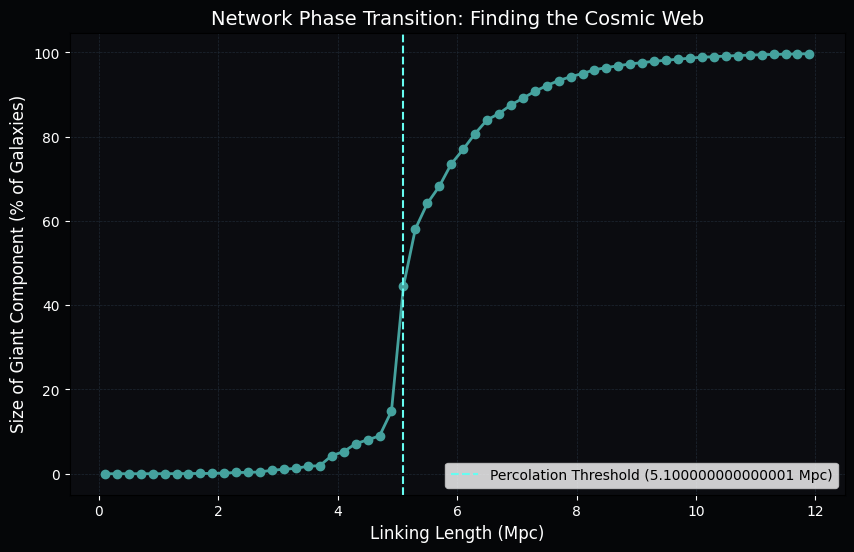

In [4]:
# we find the optimal connection radius (rc) or linking length (ll).
# This is the radius at which the largest connected component (GCC) starts to grow rapidly, indicating that galaxies are being linked together into clusters.
# we find this point by 
# so we plot the percentage of galaxies in the GCC as a function of rc to visually identify this point. 
plt.figure(figsize=(10, 6))
plt.plot(rc_values, gcc_coverage_percentages, marker='o', linestyle='-', color='#45A29E', linewidth=2)
plt.axvline(x=r_c, color='#66FCF1', linestyle='--', label=f'Percolation Threshold ({r_c} Mpc)')

plt.title("Network Phase Transition: Finding the Cosmic Web", fontsize=14, color='white')
plt.xlabel("Linking Length (Mpc)", fontsize=12, color='white')
plt.ylabel("Size of Giant Component (% of Galaxies)", fontsize=12, color='white')
plt.grid(color='#1F2833', linestyle='--', linewidth=0.5)
plt.legend()

# Dark theme styling to match a space project
plt.gca().set_facecolor('#0B0C10')
plt.gcf().patch.set_facecolor('#050608')
plt.tick_params(colors='white')

plt.show()

In [5]:
from networkx.algorithms import community as nx_comm
from sklearn.metrics import normalized_mutual_info_score
#Build the Graph using the optimal linking length
pairs = tree.query_pairs(r= r_c)

# Initialize the NetworkX Graph
G = nx.Graph()
# Add nodes (using the dataframe index: 0 to 39999)
G.add_nodes_from(range(len(my_galaxies)))
# Add the edges we found
G.add_edges_from(pairs)

print(f"Network built! Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")


# ==========================================
# 2. Run Louvain Community Detection
# ==========================================
print("\nRunning Louvain Algorithm...")

# Find the superclusters based purely on topology (NO physics data provided!)
communities = nx_comm.louvain_communities(G)

# Calculate the Modularity Score (Q)
modularity = nx_comm.modularity(G, communities)

print(f"Superclusters (Communities) found: {len(communities)}")
print(f"Modularity Score (Q): {modularity:.3f}")


# ==========================================
# 3. Validate against Ground Truth (NMI)
# ==========================================
print("\nCalculating Statistical Validation...")

# We need to map the communities back to our DataFrame
predicted_labels = [0] * len(my_galaxies)

# Loop through the communities and assign a "predicted ID" to each galaxy
for comm_id, comm in enumerate(communities):
    for node in comm:
        predicted_labels[node] = comm_id

# Save the predictions to our dataframe for later plotting
my_galaxies['Louvain_Community_ID'] = predicted_labels

# Grab the True labels we downloaded from Tempel's catalog
#removing field galaxies from the data (those with True_Cluster_ID = 0, which means they are not in any cluster)
true_labels = my_galaxies['True_Cluster_ID'] != 0

# Calculate Normalized Mutual Information (NMI)
nmi_score = normalized_mutual_info_score(my_galaxies.loc[true_labels, 'True_Cluster_ID'],
                                          my_galaxies.loc[true_labels, 'Louvain_Community_ID'])

print(f"Normalized Mutual Information (NMI): {nmi_score:.3f}")

Network built! Nodes: 145583 | Edges: 602240

Running Louvain Algorithm...
Superclusters (Communities) found: 16375
Modularity Score (Q): 0.994

Calculating Statistical Validation...
Normalized Mutual Information (NMI): 0.805


In [6]:
import plotly.express as px

print("Rendering 3D Universe...")

# 1. Isolate the top 20 largest clusters to prevent Plotly from lagging
top_20_ids = my_galaxies['Louvain_Community_ID'].value_counts().head(20).index
top_clusters_df = my_galaxies[my_galaxies['Louvain_Community_ID'].isin(top_20_ids)].copy()

# 2. Convert ID to string for discrete color mapping in Plotly
top_clusters_df['Supercluster'] = "Cluster " + top_clusters_df['Louvain_Community_ID'].astype(str)

# 3. Build the interactive 3D plot
fig = px.scatter_3d(
    top_clusters_df, 
    x='X', y='Y', z='Z', 
    color='Supercluster',
    title="Cosmic Web: Top 20 Superclusters",
    opacity=0.8
)

# 4. Keep the galaxy markers small and apply a dark space theme
fig.update_traces(marker=dict(size=2))
fig.update_layout(
    template="plotly_dark", 
    margin=dict(r=0, b=0, l=0, t=40),
    scene=dict(
        xaxis_title='X (Mpc)',
        yaxis_title='Y (Mpc)',
        zaxis_title='Z (Mpc)'
    )
)

# Display the map
fig.show()

Rendering 3D Universe...


/var/folders/t9/wl57qdf93xzg4df479bqp9_w0000gn/T/ipykernel_2327/1615211931.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', frameon=True, fontsize=10, markerscale=4)


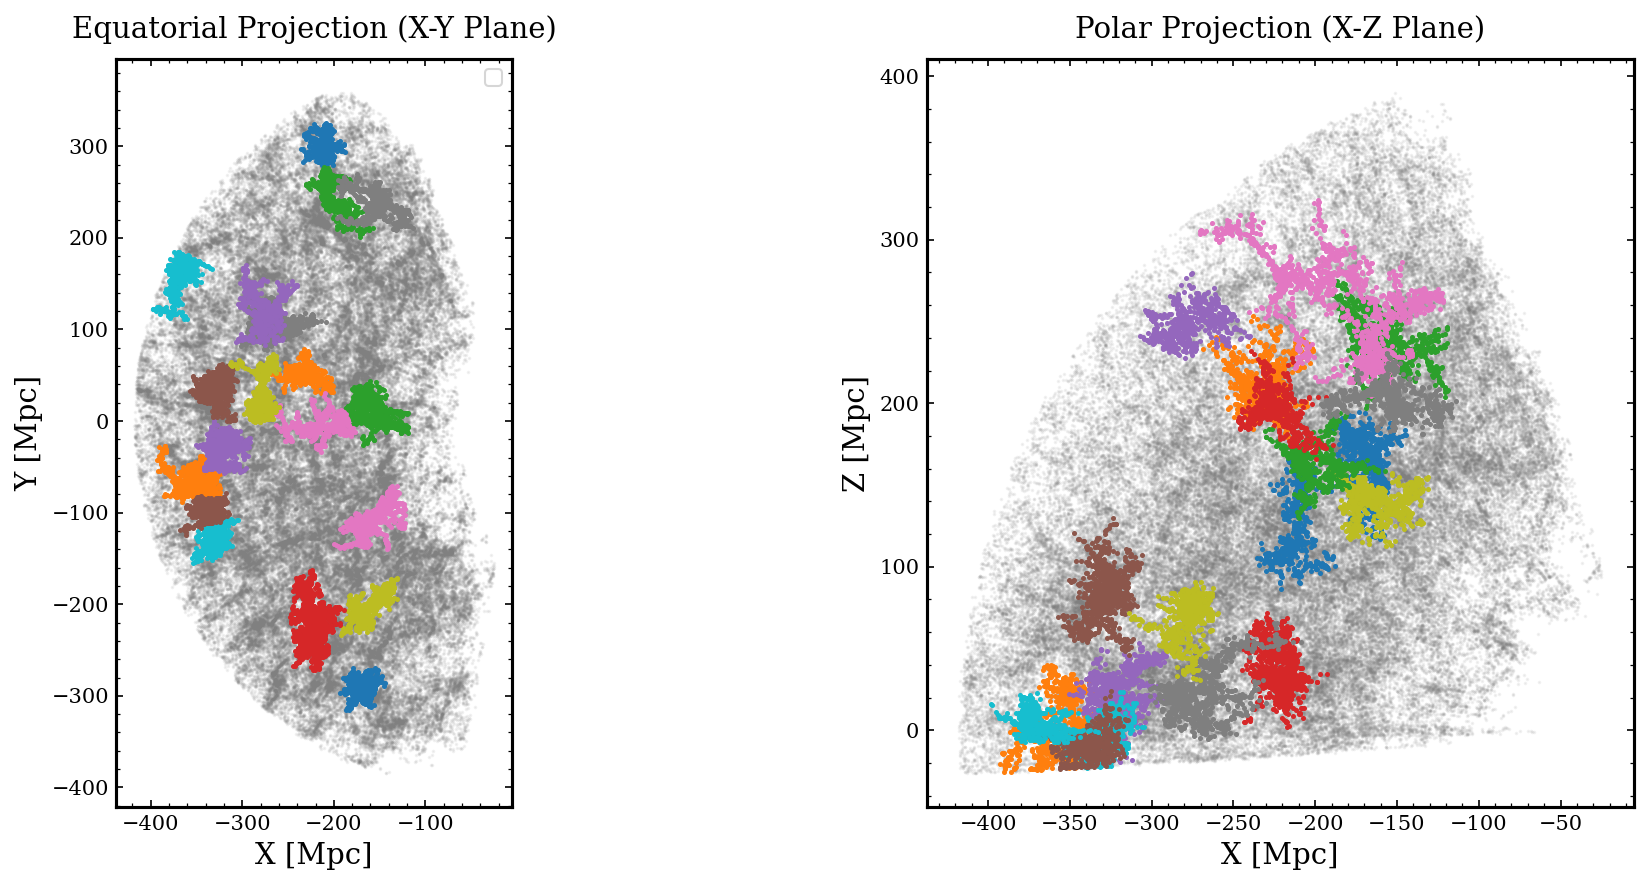

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Scientific Plot Formatting (ApJ / MNRAS standard)
plt.rcParams.update({
    'font.family': 'serif',
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
})

# 2. Setup the Figure (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# 3. Plot the background "Field" Galaxies (All 40,000 nodes)
# This shows the empty voids and true density of the slice
ax1.scatter(my_galaxies['X'], my_galaxies['Y'], s=0.5, color='gray', alpha=0.1, zorder=1)
ax2.scatter(my_galaxies['X'], my_galaxies['Z'], s=0.5, color='gray', alpha=0.1, zorder=1)

# 4. Isolate the top 20 largest superclusters
top_20_ids = my_galaxies['Louvain_Community_ID'].value_counts().head(20).index
colors = list(mcolors.TABLEAU_COLORS.values()) # Standard scientific categorical colors

# 5. Overlay the superclusters onto the projections
for i, cluster_id in enumerate(top_20_ids):
    cluster_data = my_galaxies[my_galaxies['Louvain_Community_ID'] == cluster_id]
    cluster_color = colors[i % len(colors)]  # cycle colors to avoid IndexError
    
    # X vs Y projection
    ax1.scatter(cluster_data['X'], cluster_data['Y'], s=2, 
                color=cluster_color, label=f"Cluster {cluster_id}")
    # X vs Z projection
    ax2.scatter(cluster_data['X'], cluster_data['Z'], s=2, 
                color=cluster_color, zorder=2)

# 6. Formatting Axes
ax1.set_xlabel('X [Mpc]', fontsize=14)
ax1.set_ylabel('Y [Mpc]', fontsize=14)
ax1.set_title('Equatorial Projection (X-Y Plane)', fontsize=14, pad=10)
ax1.set_aspect('equal') # Prevents spatial distortion

ax2.set_xlabel('X [Mpc]', fontsize=14)
ax2.set_ylabel('Z [Mpc]', fontsize=14)
ax2.set_title('Polar Projection (X-Z Plane)', fontsize=14, pad=10)
ax2.set_aspect('equal')

# Add legend to the first panel
ax1.legend(loc='upper right', frameon=True, fontsize=10, markerscale=4)

plt.tight_layout()
plt.show()

Generating publication-ready filament plot...


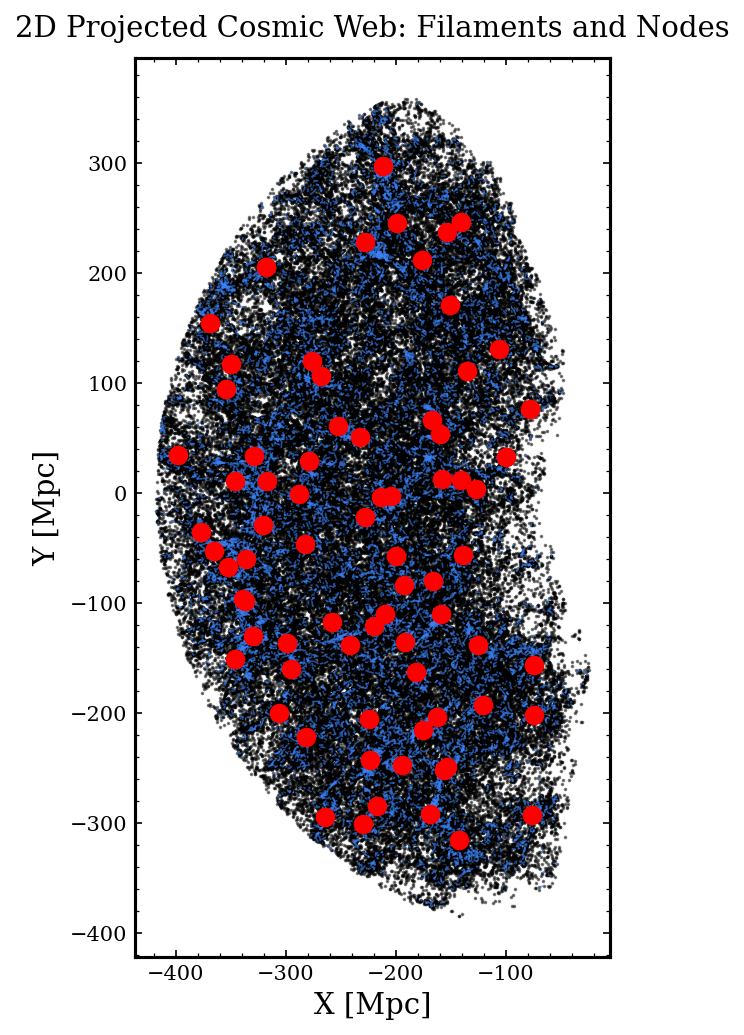

In [8]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

print("Generating publication-ready filament plot...")

fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

# 1. Scientific Formatting (Inward ticks, like the paper)
plt.rcParams.update({
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'axes.linewidth': 1.2
})

# 2. Plot the Background Galaxies (Black Dots)
# Small size and low alpha to match the paper's texture
ax.scatter(my_galaxies['X'], my_galaxies['Y'], s=0.5, color='black', alpha=0.5, zorder=1)

# 3. Calculate and Plot Massive Nodes (Red Circles)
# We isolate the 75 largest superclusters and find their center of mass
top_cluster_ids = my_galaxies['Louvain_Community_ID'].value_counts().head(75).index

cluster_centers_x = []
cluster_centers_y = []

for cid in top_cluster_ids:
    cluster_data = my_galaxies[my_galaxies['Louvain_Community_ID'] == cid]
    cluster_centers_x.append(cluster_data['X'].mean())
    cluster_centers_y.append(cluster_data['Y'].mean())

ax.scatter(cluster_centers_x, cluster_centers_y, s=70, color='red', zorder=3)

# 4. Draw the Filaments (Blue Lines)
# We extract a subset of your network edges to mimic the "spines" of the web.
# 15,000 edges is usually the sweet spot for this visual density.
edges_list = list(G.edges())
np.random.seed(42) # Keeps the drawn lines consistent
sampled_indices = np.random.choice(len(edges_list), 15000, replace=False)

lines = []
for idx in sampled_indices:
    u, v = edges_list[idx]
    # Grab the coordinates for the two connected galaxies
    x0, y0 = my_galaxies.iloc[u]['X'], my_galaxies.iloc[u]['Y']
    x1, y1 = my_galaxies.iloc[v]['X'], my_galaxies.iloc[v]['Y']
    lines.append([(x0, y0), (x1, y1)])

# LineCollection is optimized in C to draw thousands of lines instantly
lc = LineCollection(lines, colors='#3b82f6', linewidths=0.8, alpha=0.6, zorder=2)
ax.add_collection(lc)

# 5. Final Labels and Viewport
ax.set_xlabel('X [Mpc]', fontsize=14)
ax.set_ylabel('Y [Mpc]', fontsize=14)
ax.set_title('2D Projected Cosmic Web: Filaments and Nodes', fontsize=14, pad=10)

# This is critical: it prevents the universe from looking stretched
ax.set_aspect('equal') 

plt.tight_layout()
plt.show()

Initiating Phase 5: Topological Analysis...

--- Top 10 Cosmic Hubs Identified ---
             ra        dec         z  Degree  Louvain_Community_ID
340  239.283150  27.539554  0.091094      85                   213
252  239.654308  27.137992  0.090353      85                   213
257  239.664835  27.230997  0.090275      84                   213
373  239.594260  27.256722  0.090296      83                   213
327  239.605965  27.245825  0.090379      82                   213
313  239.607933  27.334752  0.090478      80                   213
339  239.266779  27.421212  0.091282      80                   213
312  239.499700  27.495372  0.091124      80                   213
321  239.579867  27.379014  0.090419      80                   213
381  239.290745  27.430538  0.091120      78                   213


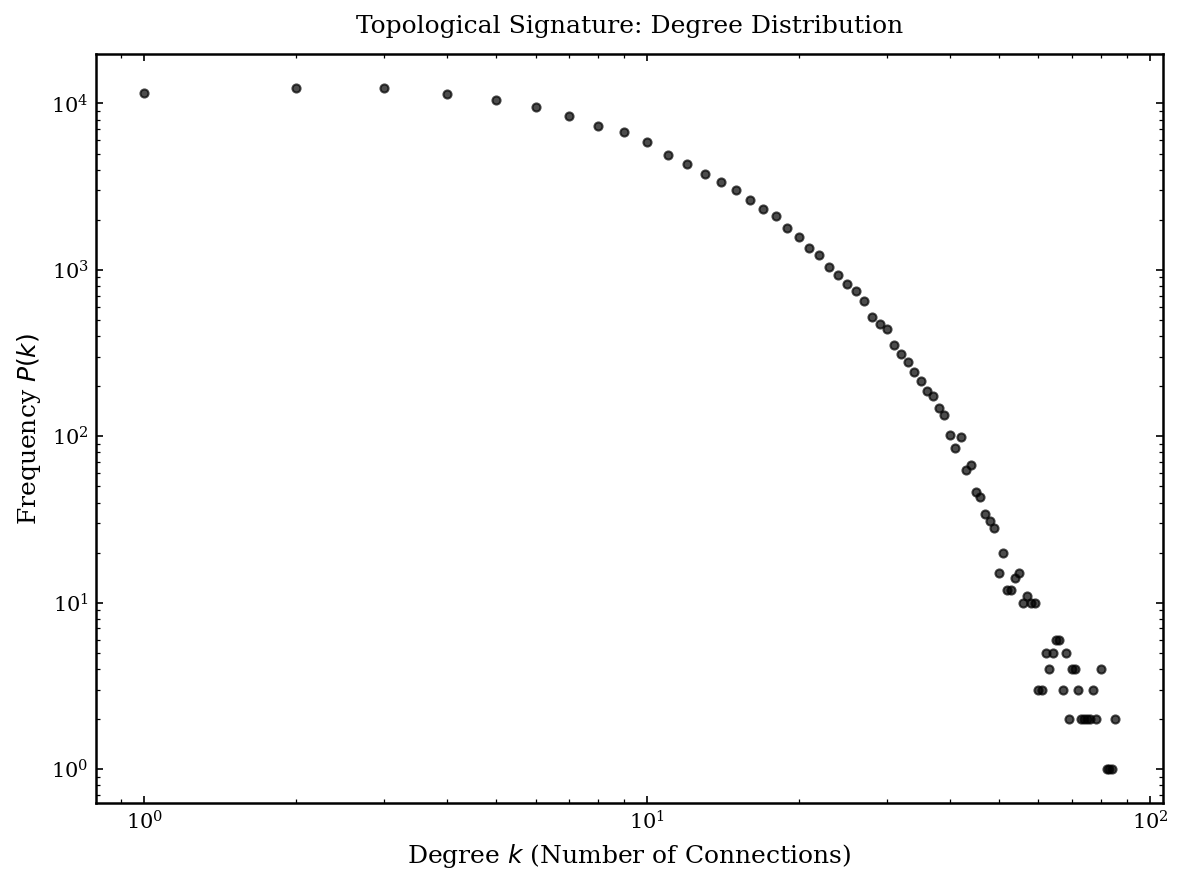

In [9]:
print("### Phase 4.1: Results Summary")
import pandas as pd
summary_data = {
    "Metric": ["Nodes", "Redshift Range", "M Limit", "Linking Length (rc)", "Edges", "Communities", "Modularity (Q)", "NMI"],
    "Value": [len(my_galaxies), f"{z_min}-{z_max}", f"{M_limit:.2f}", f"{r_c:.2f} Mpc", G.number_of_edges(), len(communities), f"{modularity:.3f}", f"{nmi_score:.3f}"]
}
display(pd.DataFrame(summary_data))

print("Initiating Phase 5: Topological Analysis...")

# 1. Calculate Degree (Connections per galaxy)
degrees = [G.degree(n) for n in G.nodes()]
my_galaxies['Degree'] = degrees

# 2. Isolate the Cosmic Hubs
top_hubs = my_galaxies.sort_values(by='Degree', ascending=False).head(10)
print("\n--- Top 10 Cosmic Hubs Identified ---")
print(top_hubs[['ra', 'dec', 'z', 'Degree', 'Louvain_Community_ID']])

# 3. Degree Distribution (Exploratory Analysis)
degree_counts = np.bincount(degrees)
degrees_x = np.nonzero(degree_counts)[0]
counts_y = degree_counts[degrees_x]

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.scatter(degrees_x, counts_y, marker='o', color='black', s=15, alpha=0.7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree k', fontsize=12)
ax.set_ylabel('Frequency P(k)', fontsize=12)
ax.set_title('Topological Signature: Exploratory Degree Distribution', fontsize=12)
plt.tight_layout()
plt.show()